<a href="https://colab.research.google.com/github/SeulGiPark-KISTI/-study/blob/main/%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%ED%8A%B9%EB%A1%A0%EA%B3%BC%EC%A0%9C_%EC%BD%94%EB%93%9C_%EB%B0%95%EC%8A%AC%EA%B8%B0_250530.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <a > Pandas를 이용하여 데이터 불러오기 </a>


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df = pd.read_csv("https://raw.githubusercontent.com/hongsukyi/Lectures/main/data/vds16.csv")

In [90]:
df.head()

,Date,ToVol,SmVol,MeVol,LaVol,Speed,OccRate
0,2017-04-02 0:00,43,34,9,0,50.3,1.90
1,2017-04-02 0:05,45,32,13,0,58.9,1.84
2,2017-04-02 0:10,46,34,12,0,50.6,1.87
3,2017-04-02 0:15,45,36,9,0,50.9,1.72
4,2017-04-02 0:20,27,13,13,1,62.2,1.12


### <a > 3개 라벨의 균일하도록 설정함 /a>

In [91]:
num_classes = 3
class_labels= ['Jam', 'Slow', 'Normal']

In [92]:
def get_score(speed):
    if speed < 45:
        label = 'Jam'
    elif speed < 50:
        label = 'Slow'
    else :
        label = 'Normal'
    return label

In [93]:
df["label"] = df["Speed"].apply(lambda spd: get_score(spd))
df.head()

,Date,ToVol,SmVol,MeVol,LaVol,Speed,OccRate,label
0,2017-04-02 0:00,43,34,9,0,50.3,1.90,Normal
1,2017-04-02 0:05,45,32,13,0,58.9,1.84,Normal
2,2017-04-02 0:10,46,34,12,0,50.6,1.87,Normal
3,2017-04-02 0:15,45,36,9,0,50.9,1.72,Normal
4,2017-04-02 0:20,27,13,13,1,62.2,1.12,Normal


In [94]:
label = df['label'].unique()
label

array(['Normal', 'Slow', 'Jam'], dtype=object)

### <a > Seaborn을 이용한 상관관계 등 가시화 </a>

<Axes: xlabel='label', ylabel='count'>

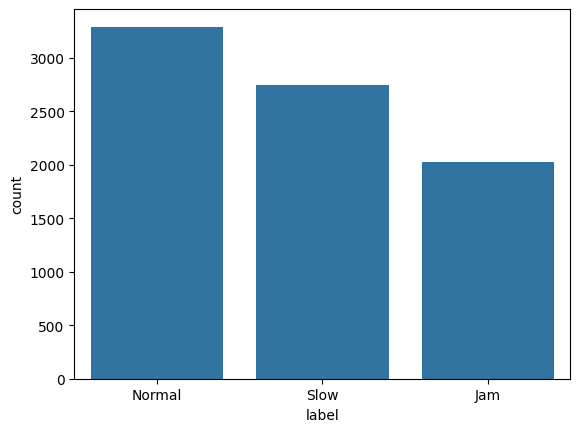

In [95]:
sns.countplot(x="label", data=df)

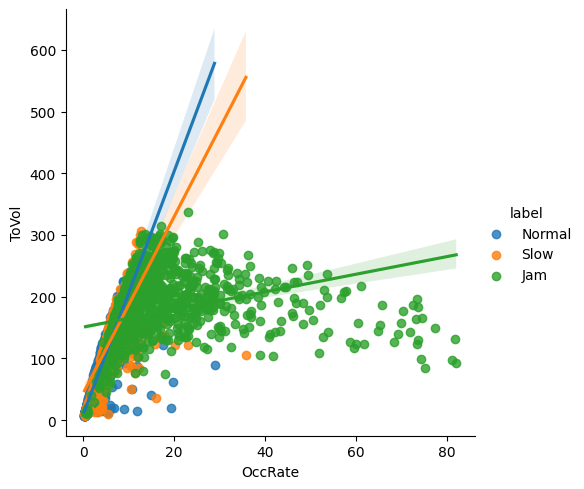

In [96]:
sns.lmplot(x="OccRate", y="ToVol", hue="label", data=df)

# <a > 머신러닝 적용하기 </a>

#### 특성과 라벨에 대하여 논의사항
- 특성 중에서 ToVol=LaVol+MeVol+SmVol이다
- Speed를 이용하여 label을 만들었다.
- Speed를 특성 포함하는 것이 올바른가? 아니면 제외하는 것이 올바른 것인가?

In [97]:
X = df[['ToVol','LaVol','MeVol','SmVol', 'Speed','OccRate']]
y = df['label']

#### sklearn.preprocessing에 LabelEncoder를 이용하자
- 라벨(y)는 텍스트로 되어 있어서 숫자로 바꾸자
- 라벨 개수 num_classes에 맞도록 LabelEncoder()로 인코딩 해보자

In [98]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [99]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [100]:
y

array([1, 1, 1, ..., 1, 1, 1])

#### X_train을 위하여 sklearn.preprocessing에 StandardScaler를 이용하자.

In [101]:
X[:5]

,ToVol,LaVol,MeVol,SmVol,Speed,OccRate
0,43,0,9,34,50.3,1.90
1,45,0,13,32,58.9,1.84
2,46,0,12,34,50.6,1.87
3,45,0,9,36,50.9,1.72
4,27,1,13,13,62.2,1.12


In [102]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [103]:
X_scaled[:5]

array([[-1.05487777, -0.75688677, -1.09793441, -0.96910406,  0.12277801,
        -0.6331216 ],
       [-1.02360358, -0.75688677, -0.88829029, -1.01183983,  1.20844949,
        -0.6420243 ],
       [-1.00796648, -0.75688677, -0.94070132, -0.96910406,  0.16065027,
        -0.63757295],
       [-1.02360358, -0.75688677, -1.09793441, -0.92636829,  0.19852253,
        -0.6598297 ],
       [-1.30507134, -0.1033334 , -0.88829029, -1.41782965,  1.62504437,
        -0.74885671]])

### <a > 의사결정 경계를 정하기 위해 교통량-점유률 경계를 알아보자 </a>
- X1 : 점유률과 교통량 관계
- X2 : 속도와 교통량 관계

In [104]:
X1=df[['OccRate','ToVol']].values

X2=df[['Speed','ToVol']].values

### <a >  Train/Test 데이터 나누기 </a >

In [105]:
import random
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report,  accuracy_score, confusion_matrix

from mlxtend.plotting import plot_decision_regions
#!pip install mlxtend

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=0)

In [107]:
print(X_train.shape, y_train.shape)
print(X_test.shape,  y_test.shape)

(5644, 6) (5644,)
(2420, 6) (2420,)


In [108]:
X_train

array([[-0.0853777 ,  1.20377333,  0.10751931, -0.19986021, -3.38671817,
         4.86726363],
       [-1.46144232, -0.75688677, -1.2551675 , -1.46056541,  1.80178158,
        -0.81711075],
       [ 0.11790457, -0.1033334 , -0.52141307,  0.37707268, -0.09183147,
        -0.08560551],
       ...,
       [ 1.3688724 ,  0.55021996,  1.26056199,  1.3386275 , -0.47055408,
         0.26605117],
       [-1.44580522, -0.75688677, -1.30757853, -1.41782965,  1.33469036,
        -0.79633778],
       [ 0.11790457,  1.20377333,  0.89368477, -0.24259598, -0.04133512,
        -0.20430819]])

# 라이브러리 임포트 및 데이터 로딩

In [109]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch 관련
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


### 특성과 라벨에 대하여 논의사항
특성 중에서 ToVol=LaVol+MeVol+SmVol이다
Speed를 이용하여 label을 만들었다.
Speed를 특성 포함하는 것이 올바른가? 아니면 제외하는 것이 올바른 것인가?

결론: Speed는 특성에서 제외하는 것이 정석적인 방식이다. 성능이 떨어지더라도 그것이 진짜 모델의 일반화 성능이다. 단, 비교 실험 용도로 포함한 버전도 만들어보는 건 학습적으로 유익하다고 한다.

In [110]:
# 데이터 로드 및 라벨링
df = pd.read_csv("https://raw.githubusercontent.com/hongsukyi/Lectures/main/data/vds16.csv")

q1 = df['Speed'].quantile(0.33)
q2 = df['Speed'].quantile(0.66)

def get_score_qnt(speed):
    if speed < q1:
        return 'Jam'
    elif speed < q2:
        return 'Slow'
    else:
        return 'Normal'

df['label'] = df['Speed'].apply(get_score)
df.head()


,Date,ToVol,SmVol,MeVol,LaVol,Speed,OccRate,label
0,2017-04-02 0:00,43,34,9,0,50.3,1.90,Normal
1,2017-04-02 0:05,45,32,13,0,58.9,1.84,Normal
2,2017-04-02 0:10,46,34,12,0,50.6,1.87,Normal
3,2017-04-02 0:15,45,36,9,0,50.9,1.72,Normal
4,2017-04-02 0:20,27,13,13,1,62.2,1.12,Normal


Text(0.5, 1.0, 'Speed Value Distribution')

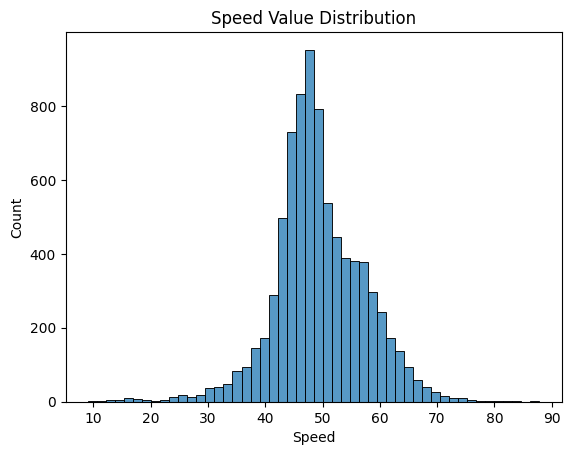

In [111]:
import matplotlib.pyplot as plt
sns.histplot(df["Speed"], bins=50)
plt.title("Speed Value Distribution")

In [112]:
# Hour 파생 (Date 열이 문자열로 들어있다고 가정)
df['Hour'] = df['Date'].astype(str).str[9:11].astype(int)

# rho = 밀도 = ToVol / (OccRate + 1e-5)
df['rho'] = df['ToVol'] / (df['OccRate'] + 1e-5)
X = df[['ToVol', 'Speed', 'Hour', 'rho']]
y = df['label']


In [113]:
import random
import numpy as np
import tensorflow as tf
import os

# Python random seed
random.seed(42)

# NumPy random seed
np.random.seed(42)

# TensorFlow random seed
tf.random.set_seed(42)

# GPU 동작의 재현성 보장 (필요시)
os.environ['TF_DETERMINISTIC_OPS'] = '1'


# 전처리: 특성 선택, 정규화, 인코딩

In [114]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 특성 선택 (Speed + 시간 + 밀도 + 총량)
X = df[['ToVol', 'Speed', 'Hour', 'rho']]
y = df['label']  # 문자열 라벨 (예: 'Jam', 'Slow', 'Normal')

#레이블 인코딩
le = LabelEncoder()
y_enc = le.fit_transform(y)  # y → 정수 인코딩

# 정규화 (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified Shuffle Split (클래스 비율 유지)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss.split(X_scaled, y_enc):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]


# 텐서 변환 및 데이터 로더

In [115]:
# NumPy → Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


# SVM 모델 정의

In [116]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


SVM Accuracy: 0.9727216367017979
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       405
           1       0.99      0.97      0.98       658
           2       0.94      0.98      0.96       550

    accuracy                           0.97      1613
   macro avg       0.97      0.97      0.97      1613
weighted avg       0.97      0.97      0.97      1613



# ANN (MLPClassifier)

In [117]:
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
ann_model.fit(X_train, y_train)
y_pred = ann_model.predict(X_test)

print("ANN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ANN Accuracy: 0.9956602603843769
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       405
           1       1.00      1.00      1.00       658
           2       0.99      0.99      0.99       550

    accuracy                           1.00      1613
   macro avg       1.00      0.99      1.00      1613
weighted avg       1.00      1.00      1.00      1613



# DNN (Keras)

In [118]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# 클래스 수
num_classes = len(np.unique(y_enc))

# Learning Rate Scheduler 정의 (CosineAnnealing)
initial_lr = 1e-3
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_lr,
    first_decay_steps=10,      # 학습률이 줄어드는 주기 (epoch 단위)
    t_mul=2.0,                 # decay 주기를 늘리는 비율
    m_mul=1.0,                 # 최소 learning rate 비율 유지
    alpha=1e-6                 # 최소 learning rate
)

# Optimizer 정의 (AdamW)
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-2
)

# 모델 정의
dnn_model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='swish'),
    Dropout(0.3),
    Dense(32, activation='swish'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# 컴파일
dnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 모델 학습
history = dnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 테스트셋 성능 평가
loss, acc = dnn_model.evaluate(X_test, y_test, verbose=0)
print("최종 DNN Accuracy on Test Set:", round(acc * 100, 2), "%")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6763 - loss: 0.8256 - val_accuracy: 0.8304 - val_loss: 0.5147
Epoch 2/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8389 - loss: 0.4603 - val_accuracy: 0.8892 - val_loss: 0.3689
Epoch 3/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9056 - loss: 0.3196 - val_accuracy: 0.9450 - val_loss: 0.2165
Epoch 4/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9319 - loss: 0.2219 - val_accuracy: 0.9589 - val_loss: 0.1859
Epoch 5/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9407 - loss: 0.1825 - val_accuracy: 0.9744 - val_loss: 0.1198
Epoch 6/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9478 - loss: 0.1386 - val_accuracy: 0.9861 - val_loss: 0.0976
Epoch 7/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9550 - loss: 0.1206 - val_accuracy: 0.9899 - val_loss: 0.0899
Epoch 8/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9552 - loss: 0.1173 - val_accuracy: 0.985

# 결과 시각화

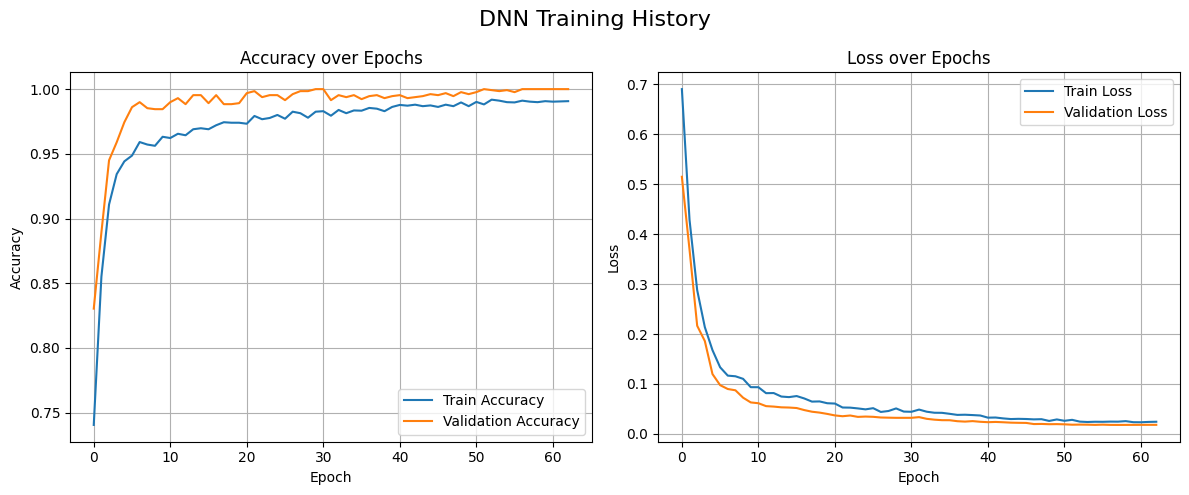

In [119]:
import matplotlib.pyplot as plt

# 학습 정확도 & 검증 정확도
plt.figure(figsize=(12, 5))

# --- Accuracy 그래프 ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Loss 그래프 ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle("DNN Training History", fontsize=16)
plt.tight_layout()
plt.show()


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


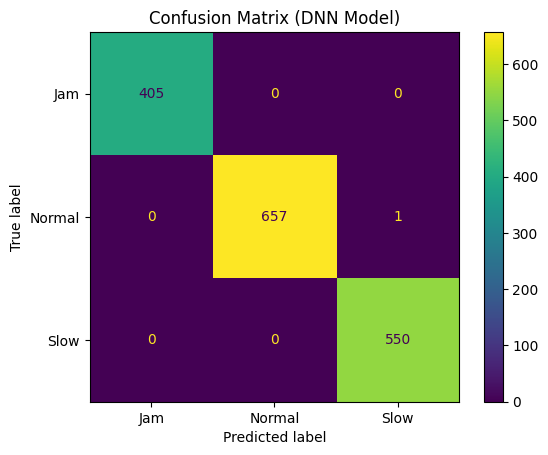

              precision    recall  f1-score   support

         Jam       1.00      1.00      1.00       405
      Normal       1.00      1.00      1.00       658
        Slow       1.00      1.00      1.00       550

    accuracy                           1.00      1613
   macro avg       1.00      1.00      1.00      1613
weighted avg       1.00      1.00      1.00      1613



In [121]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np

# 예측값 → 클래스 인덱스로 변환
y_pred = dnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# 혼동 행렬 생성
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='viridis')
plt.title("Confusion Matrix (DNN Model)")
plt.grid(False)
plt.show()

# 정밀한 성능 평가 출력
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))
